# OpenAI Image & Vision

https://platform.openai.com/docs/guides/images-vision?format=url

In [2]:
%pip install dotenv openai

  Using cached dotenv-0.9.9-py2.py3-none-any.whl.metadata (279 bytes)
  Using cached python_dotenv-1.2.3-py3-none-any.whl.metadata (29 kB)
  Using cached httpx2-2.12.0-py3-none-any.whl.metadata (9.5 kB)
  Using cached pydantic-2.13.5-py3-none-any.whl.metadata (110 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached httpcore2-2.12.0-py3-none-any.whl.metadata (25 kB)
  Using cached truststore-0.10.4-py3-none-any.whl.metadata (4.4 kB)
  Using cached annotated_types-0.8.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.5-cp312-cp312-win_amd64.whl.metadata (6.7 kB)
  Using cached typing_inspection-0.4.4-py3-none-any.whl.metadata (2.6 kB)
Using cached dotenv-0.9.9-py2.py3-none-any.whl (1.9 kB)
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 37.2 MB/s  0:00:00
Using cached httpx2-2.12.0-py3-none-any.whl (95 kB)
Using cached httpcore2-2.12.0-py3-none-any.whl (83 kB)
Us

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [5]:
from openai import OpenAI
import base64  # 이미지 파일 저장용

client = OpenAI()

response = client.responses.create(
    model = 'gpt-6-astra',
    input = "Generate an image of gray tabby cat hugging an otter with an orange scarf",
    tools = [
        {
            'type': 'image_generation',         # 이미지 생성도구
            'model': 'gpt-image-2.5-sunburst'
        }
    ]
)

image_data = [
    output.result                  # base64 결과
    for output in response.output
    if output.type == 'image_generation_call'  # 이미지 생성 결과만
]

if image_data:
    image_base64 = image_data[0]

    # base64로 디코딩해 PNG파일로 저장
    with open("otter.png", "wb") as f:
        f.write(base64.b64decode(image_base64))

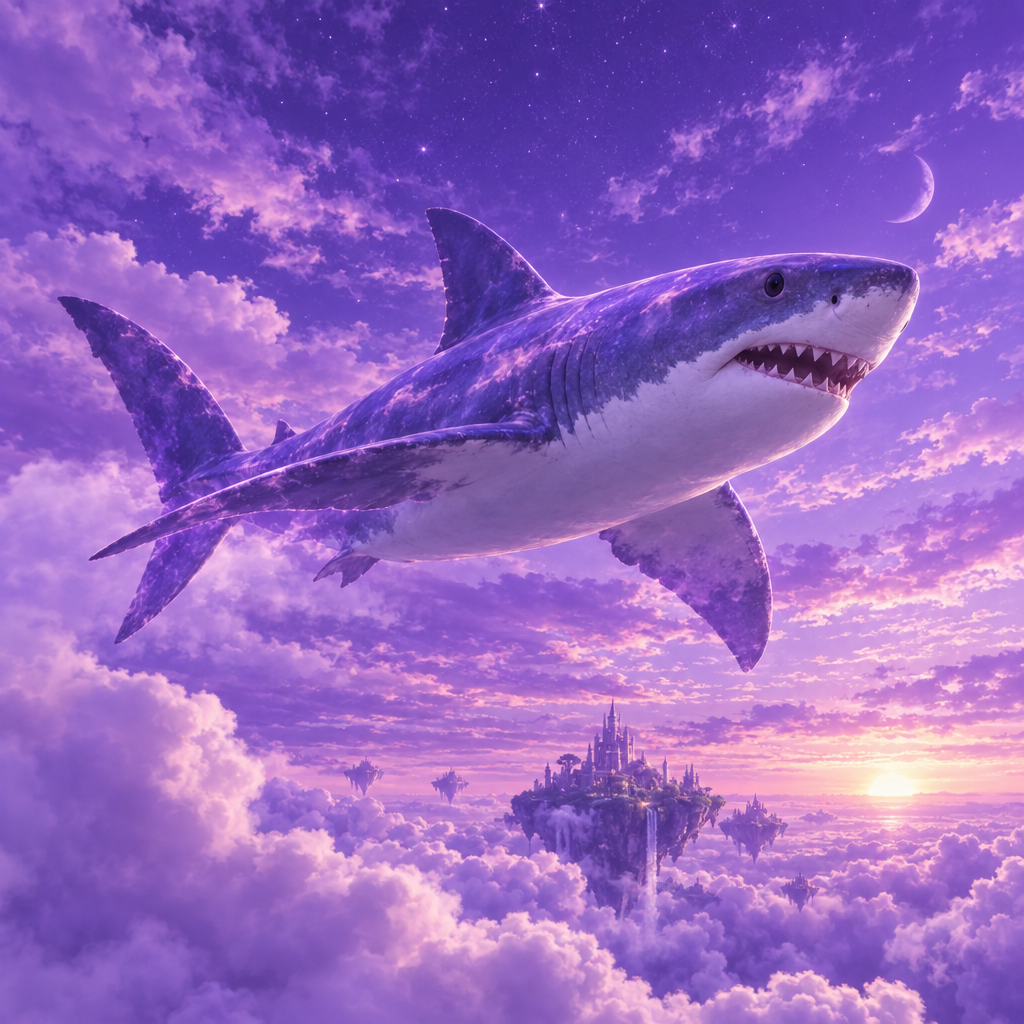

In [ ]:
from io import BytesIO  # bytes 데이터를 파일처럼 조작
from PIL import Image
from IPython.display import display  # 노트북 환경에서 각종 출력

def generate_image(prompt: str):
    response = client.images.generate(
        model = 'gpt-image-2.5-flare',
        prompt = prompt,
        size = "1024x1024",
        quality = 'high',
        output_format = 'png'
    )

    b64 = response.data[0].b64_json      # 생성된 이미지의 base64 문자열
    img_bytes = base64.b64decode(b64)    # base64 이미지 -> bytes 로 변환

    img = Image.open(BytesIO(img_bytes))  # bytes 데이터를 이미지로 열기
    display(img)  # 노트북 화면에 출력

generate_image('보라빛 하늘을 날아다니는 상어')

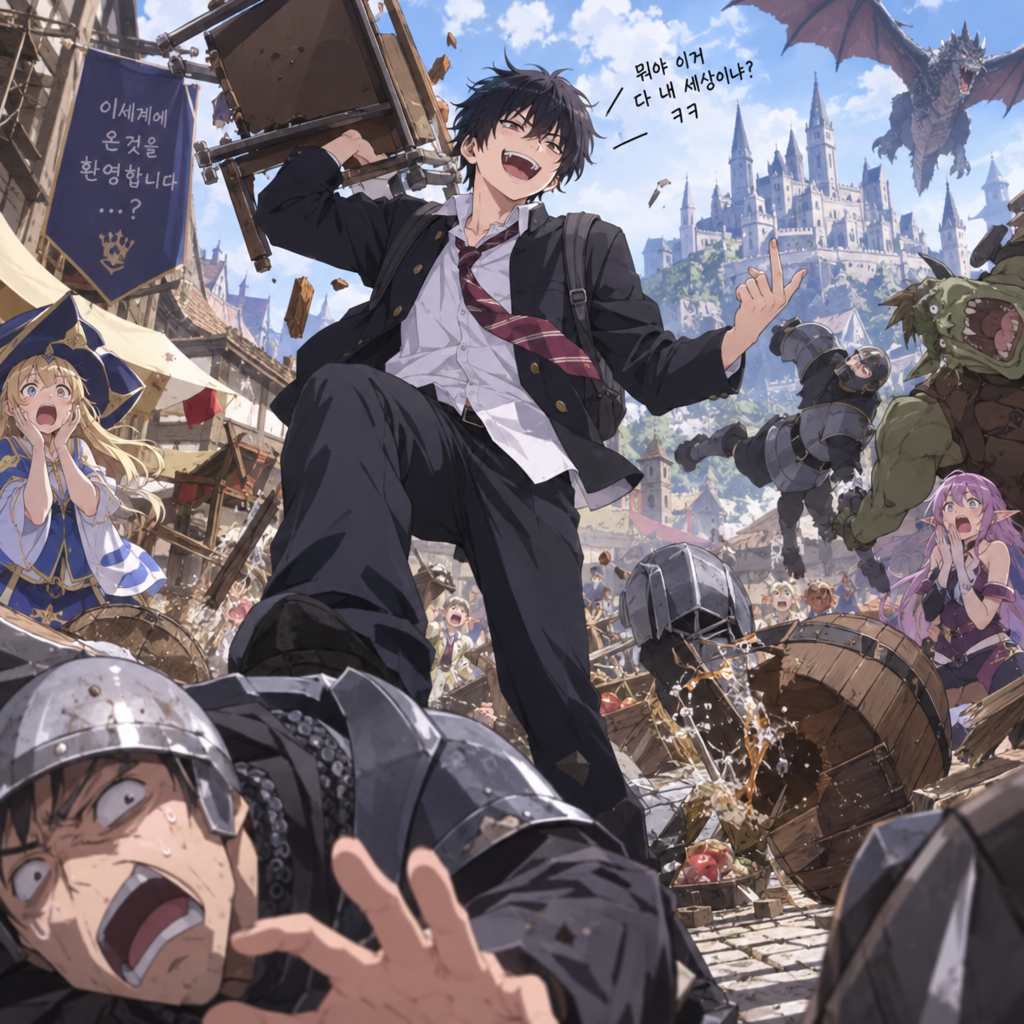

In [8]:
generate_image('이세계에서 고등학생이 깽판치는 장면')